tf_flowers: This is a widely used dataset containing approximately 3,700 images across five common classes: daisy, dandelion, roses, sunflowers, and tulips. These flower groups(classes) are (i) Daisy, (ii) Dandelion, (iii) Roses, (iv) Sunflowers, and (v) Tulips. This image dataset stored on disk which are in jpg format.

In [ ]:
# Import necessary libraries

import matplotlib.pyplot as plt
import numpy as np
import os
import PIL  # Python Imaging Library (PIL)
import tensorflow as tf # TensorFlow is an open-source machine learning framework created by the Google Brain team
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import glob # The glob module finds all the pathnames matching a specified pattern
import pathlib #  Representing filesystem paths with semantics appropriate for different operating systems
import matplotlib
import matplotlib.image as mpimg # to display an image (a NumPy array) in a Matplotlib plot. It interprets a 2D array as a grayscale image by default, using a colormap, and a 3D array as an RGB or RGBA image.
import tarfile
import sys
from collections import Counter

In [ ]:
# Check versions
print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__) # tf.version.VERSION
print("Keras version:", tf.keras.__version__)
print("Python version",sys.version)
#print("Py Plot version:",plt.__version__)
print("Matplotlib version: " , matplotlib.__version__)

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.10.0
Python version 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Matplotlib version:  3.10.0


In [ ]:
# Download and explore the dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz" # A compressed archive (tar + gzip)
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True) # Download and Unzips / untars the .tgz file
# Returns the path to the extracted folder
data_dir = pathlib.Path(data_dir) / "flower_photos"

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [ ]:
# check the directory
print(data_dir)
print([p.name for p in data_dir.iterdir()])


/root/.keras/datasets/flower_photos/flower_photos
['daisy', 'sunflowers', 'LICENSE.txt', 'roses', 'tulips', 'dandelion']


In [ ]:
# Count total number of images in the dataset. daisy: 633, dandelion: 898, roses: 641, sunflowers: 699,  tulips: 799
# Daisy
daisy_count = len(list(data_dir.glob('daisy/*.jpg'))) # The glob module finds all the pathnames matching a specified pattern
# Dandelion
dandelion_count = len(list(data_dir.glob('dandelion/*.jpg')))
# Roses
roses_count = len(list(data_dir.glob('roses/*.jpg')))
# Sunflowers
sunflowers_count = len(list(data_dir.glob('sunflowers/*.jpg')))
# Tulips
tulips_count = len(list(data_dir.glob('tulips/*.jpg')))

# Total
# Total flowers. All subfolders, then all jpg files
image_count = len(list(data_dir.glob('*/*.jpg')))

# Display
print("Total number of Daisy: ",daisy_count)
print("Total number of Dandelion: ",dandelion_count)
print("Total number of Roses: ",roses_count)
print("Total number of Sunflowers: ",sunflowers_count)
print("Total number of Tulips: ",tulips_count)
print("Total number of images in the dataset: ",image_count)

Total number of Daisy:  633
Total number of Dandelion:  898
Total number of Roses:  641
Total number of Sunflowers:  699
Total number of Tulips:  799
Total number of images in the dataset:  3670


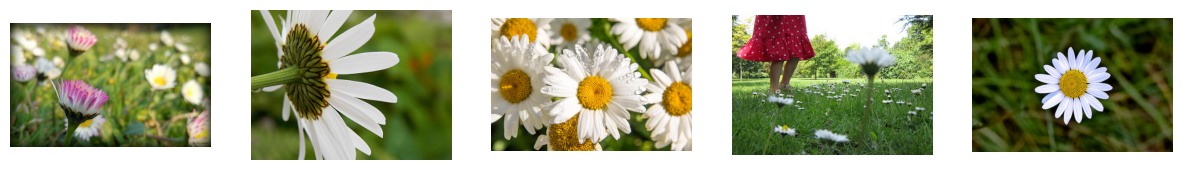

In [ ]:
# Let's look into only "daisy" subfolder
daisies = list(data_dir.glob('daisy/*'))
#PIL.Image.open(roses[1])
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(daisies[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

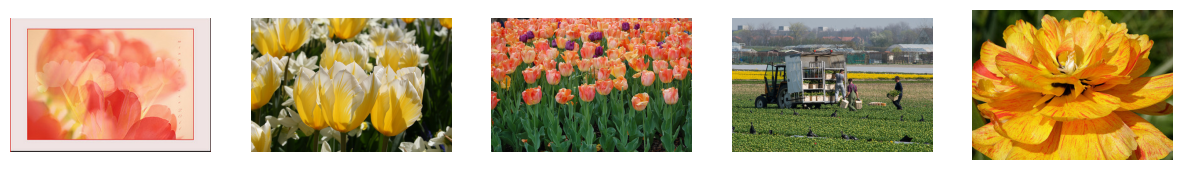

In [ ]:
# Display some tulips
tulips = list(data_dir.glob('tulips/*'))
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(tulips[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

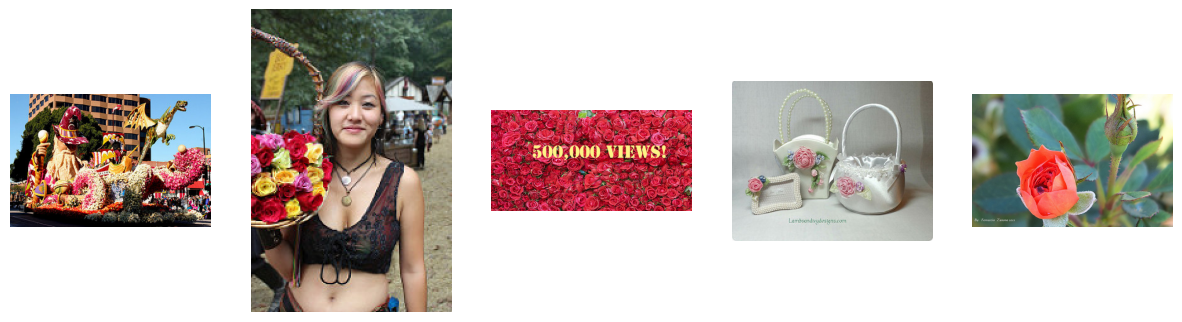

In [ ]:
# Display some tulips
roses = list(data_dir.glob('roses/*'))
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(roses[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [ ]:
# Create a dataset for ML model
# Parameters, Set image size and number of images in each batch
'''
Resize images to 32×32 so we can use the original LeNet-5 geometry (5×5 conv + pooling + 5×5 conv + pooling + 5×5 conv → 1×1×120).
'''
batch_size = 32
img_height = 32
img_width  = 32

In [ ]:
# Data preprocessing
# Generates a tf.data.Dataset from image files in a directory by using tf.keras.preprocessing.image_dataset_from_directory.
# It automatically loads images, assigns labels, resizes them, batches them, and creates a training dataset.
# The tf.keras.preprocessing.image_dataset_from_directory() utility function in TensorFlow is used to generate a tf.data.Dataset object from image files organized in a directory structure.

# Split the image dataset into 8:2. Use 80% of the images for training, and 20% for validation
#In the original 1998 LeNet-5 paper ("Gradient-Based Learning Applied to Document Recognition" by Yann LeCun et al.), there was no standard "validation split" of the training set

# Training data set
train_ds = tf.keras.preprocessing.image_dataset_from_directory( # https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123, # Endure reproducibiliy. Without this Every run may create a different random split.
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
# Count images per class from train_ds
# Get class names (folder names in order of labels)
class_names = train_ds.class_names
print("Class names:", class_names)

# Initialize counter
counter = Counter()

# Loop through all batches in train_ds
for images, labels in train_ds:
    counter.update(labels.numpy())

# Display counts
total = 0
print("\nNumber of images per class in TRAINING set:")
for i, class_name in enumerate(class_names):
    count = counter[i]
    total += count
    print(f"{class_name:12s}: {count} images")

print("\nTotal training images:", total)

Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Number of images per class in TRAINING set:
daisy       : 504 images
dandelion   : 722 images
roses       : 521 images
sunflowers  : 547 images
tulips      : 642 images

Total training images: 2936


In [ ]:
# validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
# Count images per class from val_ds
# Get class names (folder names in order of labels)
class_names = val_ds.class_names
print("Class names:", class_names)

# Initialize counter
counter = Counter()

# Loop through all batches in train_ds
for images, labels in val_ds:
    counter.update(labels.numpy())

# Display counts
total = 0
print("\nNumber of images per class in Validation set:")
for i, class_name in enumerate(class_names):
    count = counter[i]
    total += count
    print(f"{class_name:12s}: {count} images")

print("\nTotal validation images:", total)

Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Number of images per class in Validation set:
daisy       : 129 images
dandelion   : 176 images
roses       : 120 images
sunflowers  : 152 images
tulips      : 157 images

Total validation images: 734


In [ ]:
# check the class names in the class_names attribute on these datasets
class_names = train_ds.class_names
print("Training data:",class_names)
val_class_names = val_ds.class_names
print("Validation data:",val_class_names)

Training data: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Validation data: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


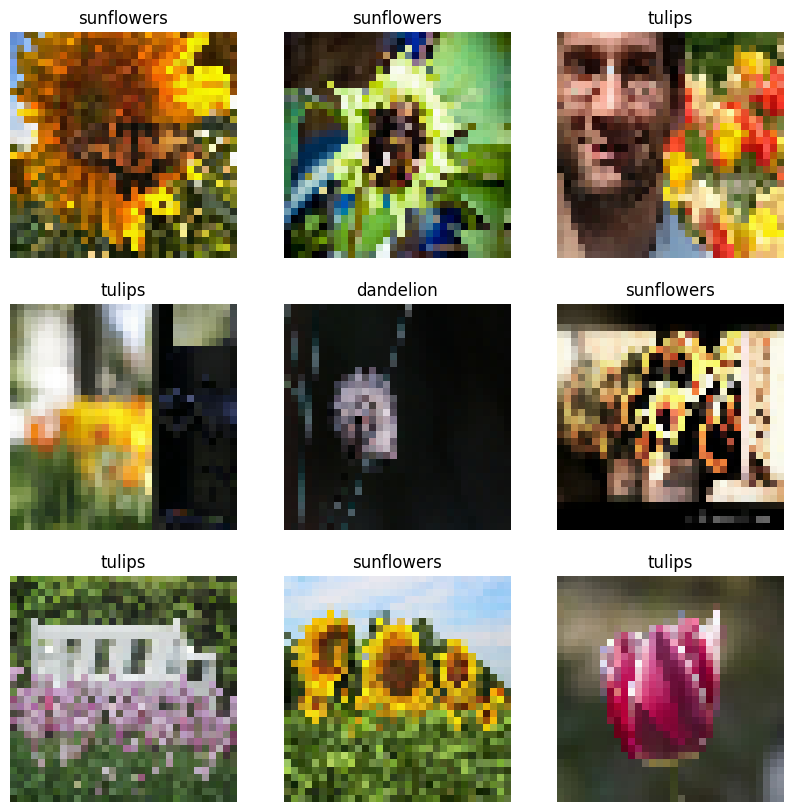

In [ ]:
# Visualize the data
# Show 9 images from train dataset with image labels.
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
# To get information about a numpy array, you can use .shape and .dtype
# The image_batch is a tensor of the shape (32, 180, 180, 3). This is a batch of 32 images of shape 180x180x3 (the last dimension refers to color channels RGB).
# The label_batch is a tensor of the shape (32,), these are corresponding labels to the 32 images.


for image_batch, labels_batch in train_ds:
   print("Shape of image batch:", image_batch.shape)
   print("Data type of image batch:", image_batch.dtype)
   print("Shape of label batch:", labels_batch.shape)
   print("Data type of label batch:", labels_batch.dtype)
   break


Shape of image batch: (32, 32, 32, 3)
Data type of image batch: <dtype: 'float32'>
Shape of label batch: (32,)
Data type of label batch: <dtype: 'int32'>


In [ ]:
# Configure the dataset for performance
# This block is not about learning, but about making the CNN training much faster and more efficient by optimizing the data input pipeline. This is a performance optimization pipeline using TensorFlow’s tf.data API.
# Use buffered prefetching to yield data from disk without having I/O become blocking
# Dataset.cache() keeps the images in memory after they're loaded off disk during the first epoch.
# This will ensure the dataset does not become a bottleneck while training your model.
# Dataset.prefetch() overlaps data preprocessing and model execution while training.

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Standardize the data
# Preprocess images by normalizing the pixel values to be in the [0, 1] range (originally all values are in the [0, 255] range).
# All images will be rescaled by 1./255 (min-max normalization)
# Without normalization, Gradients can explode or vanish, and Training becomes slower and unstable

# Take one batch (1st) from the training dataset
image_batch, labels_batch = next(iter(train_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print("Before Normalization: ",np.min(first_image), np.max(first_image))

# Rescaling layer (min-max)
normalization_layer = layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# Take one batch (1st) from the normalized dataset
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print("After Normalization: ", np.min(first_image), np.max(first_image))

Before Normalization:  0.0 254.32812
After Normalization:  0.0 1.0


In [ ]:
# Create the model
# The model consists of three convolution blocks with a max pool layer in each of them.
# There's a fully connected layer with 128 units on top of it that is activated by a relu activation function.

num_classes = 5

lenet_model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    #layers.Rescaling(1./255),  # normalize [0,255] -> [0,1]
    #layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # C1: 6 filters, 5x5 -> (32-5+1)=28 => 28x28x6
    layers.Conv2D(6, (5, 5), activation="tanh", padding="valid"),

    # S2: average pooling -> 14x14x6
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    # C3: 16 filters, 5x5 -> 10x10x16
    layers.Conv2D(16, (5, 5), activation="tanh", padding="valid"),

    # S4: average pooling -> 5x5x16
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    # C5: 120 filters, 5x5 -> 1x1x120 (acts like FC)
    layers.Conv2D(120, (5, 5), activation="tanh", padding="valid"),

    layers.Flatten(),  # -> 120

    # F6: 84
    layers.Dense(84, activation="tanh"),

    # Output: logits for 5 classes
    layers.Dense(num_classes) # there is no built-in rbf activation function in keras
])


In [ ]:
# Compile the model
# Using the optimizers as Adam optimizer and losses, SparseCategoricalCrossentropy loss function.
# To view training and validation accuracy for each training epoch, pass the metrics argument.

lenet_model.compile(optimizer='adam',
                    # optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
# Model summary
lenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,581 (240.55 KB)

 Trainable params: 61,581 (240.55 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
epochs=20
history = lenet_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  verbose = 2
)

Epoch 1/20
92/92 - 8s - 90ms/step - accuracy: 0.3822 - loss: 1.3791 - val_accuracy: 0.4537 - val_loss: 1.2686
Epoch 2/20
92/92 - 0s - 4ms/step - accuracy: 0.4550 - loss: 1.2626 - val_accuracy: 0.4768 - val_loss: 1.2459
Epoch 3/20
92/92 - 0s - 4ms/step - accuracy: 0.4751 - loss: 1.2377 - val_accuracy: 0.4687 - val_loss: 1.2508
Epoch 4/20
92/92 - 0s - 4ms/step - accuracy: 0.4884 - loss: 1.2233 - val_accuracy: 0.4809 - val_loss: 1.2312
Epoch 5/20
92/92 - 0s - 5ms/step - accuracy: 0.4799 - loss: 1.2147 - val_accuracy: 0.5095 - val_loss: 1.2379
Epoch 6/20
92/92 - 0s - 4ms/step - accuracy: 0.4894 - loss: 1.2005 - val_accuracy: 0.4809 - val_loss: 1.2504
Epoch 7/20
92/92 - 0s - 4ms/step - accuracy: 0.5095 - loss: 1.1799 - val_accuracy: 0.4741 - val_loss: 1.2479
Epoch 8/20
92/92 - 0s - 4ms/step - accuracy: 0.5215 - loss: 1.1653 - val_accuracy: 0.4850 - val_loss: 1.2290
Epoch 9/20
92/92 - 0s - 4ms/step - accuracy: 0.5191 - loss: 1.1647 - val_accuracy: 0.4891 - val_loss: 1.2560
Epoch 10/20
92/92 

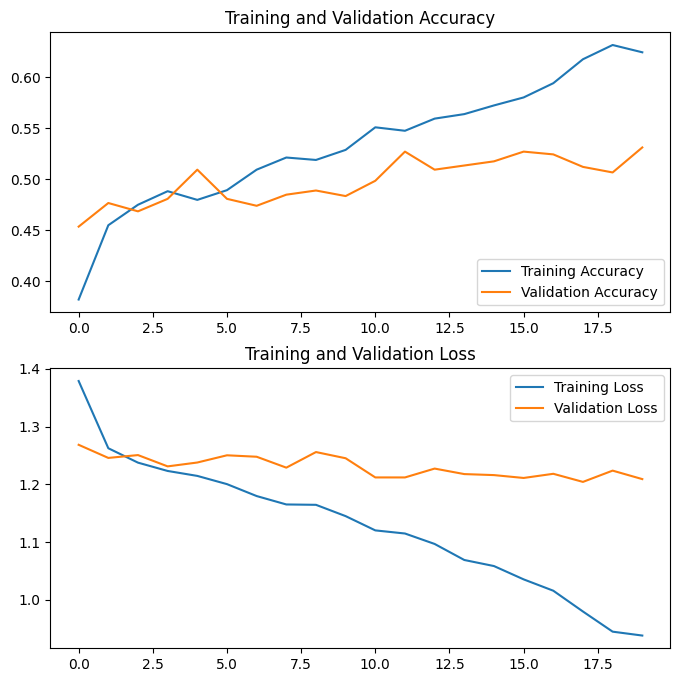

In [ ]:
# Visualize training results
# Create plots of loss and accuracy on the training and validation sets

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [ ]:
# print maximun accuracy on traning and validation data
# In the plots above, the training accuracy is increasing linearly over time, whereas validation accuracy stalls around 60% in the training process.
# Also, the difference in accuracy between training and validation accuracy is noticeable—a sign of overfitting.

print("Training Data Accuracy:",max(acc))
print("Validation Data Accuracy",max(val_acc))

Training Data Accuracy: 0.6318119764328003
Validation Data Accuracy 0.531335175037384


# What can we do to tackle overfitting issues?